# Análisis y Procesamiento de Señales

## Trabajo Práctico N°3

### Ferreyra Valentina

#### Introducción

En este trabajo práctico se analizará el desparramo espectral que aparece cuando la frecuencia de una señal no coincide con uno de los bins de la DFT. También se estudiará la técnica de zero padding para obtener una representación más densa del espectro en frecuencia. Finalmente, se verificará mediante la identidad de Parseval que la potencia calculada en el dominio del tiempo coincide con la potencia calculada en el dominio de la frecuencia.

### A.

In [15]:
import numpy as np
import matplotlib.pyplot as plt

In [16]:
N = 1000
fs = 1000
k = N/4 
vmax = np.sqrt(2) 
dc = 0
ph = 0
ff = k*(fs/N)

En este primer caso, según la consigna, se toma $k=\frac{N}{4}$. Como $N=1000$, se obtiene $k=250$. La frecuencia de la senoide se calcula como $f_0=k\cdot\Delta f$, donde $\Delta f=\frac{f_s}{N}$. Como $f_s=1000,Hz$ y $N=1000$, resulta $\Delta f=1,Hz$, por lo que la frecuencia de la señal es $f_0=250\cdot1=250,Hz$. De esta manera, la frecuencia de la senoide coincide exactamente con uno de los bins de la DFT, por lo que esperamos que la potencia quede concentrada principalmente en esa componente frecuencial y que prácticamente no haya desparramo espectral.

In [17]:
def mi_funcion_sen(k):
    n = np.arange(N) / fs
    xx = dc + vmax * np.sin(2*np.pi*k*(fs/N)*n + ph)
    return (n,xx)

In [18]:
n,xx = mi_funcion_sen(k)

eje_frec = np.arange(0, N//2) * fs/N 

yf = 1/N * np.fft.fft(xx)

XX_mod = np.abs(yf)

espectro = (XX_mod)**2
dens_espc = 10*np.log10(2*(espectro[:N//2]))

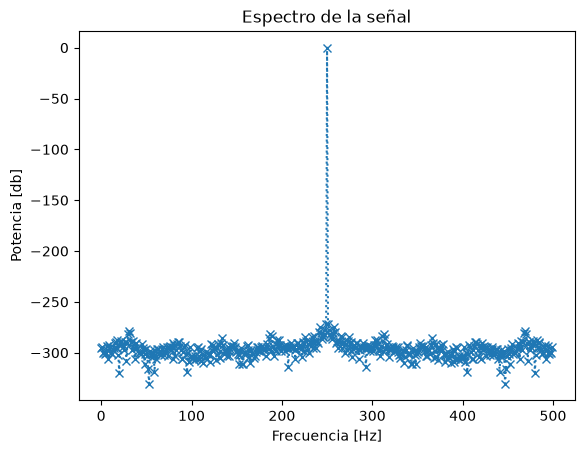

In [19]:
plt.plot(eje_frec, dens_espc,':x')
plt.title("Espectro de la señal")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Potencia [db]")
plt.show()

En el gráfico se observa que el pico se encuentra exactamente en el bin correspondiente a $250 \ Hz$, tal como se esperaba. Además, el pico alcanza aproximadamente $0 \ dB$, ya que se definió una señal de potencia unitaria y, al coincidir la frecuencia de la senoide con uno de los bins de la DFT, esa potencia queda concentrada principalmente en dicha componente frecuencial. En los demás bins la potencia es prácticamente nula, por lo que en este caso no se observa un desparramo espectral significativo.

En el segundo caso, donde $k =\ 250.25$, la frecuencia de la senoide ya no coincide exactamente con uno de los bins de la DFT. Por este motivo, la potencia no queda concentrada en una única componente frecuencial, sino que aparece distribuida entre varios bins cercanos, produciendo desparramo espectral.

In [20]:
n,xx2 = mi_funcion_sen(k+0.25)

eje_frec = np.arange(0, N//2, fs/N) * fs/N #Nos prepara la FFT

yf2 = 1/N * np.fft.fft(xx2)

XX_mod2 = np.abs(yf2)

espectro2 = (XX_mod2)**2
dens_espc2 =  10*np.log10(2*(espectro2[:N//2])) 

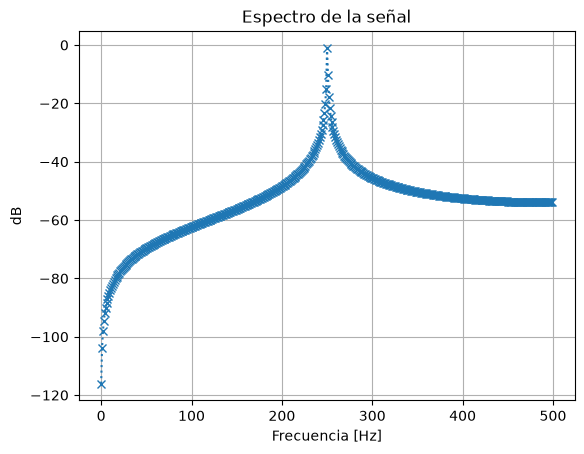

In [21]:
plt.figure()
plt.plot(eje_frec, dens_espc2,':x')
plt.title("Espectro de la señal")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("dB")
#plt.ylim(-80, 0)
plt.grid()
plt.show()

En este segundo caso, la frecuencia de la señal es $250.25\,Hz$, por lo que ya no coincide exactamente con uno de los bins de la DFT. El pico principal aparece aproximadamente en $250\,Hz$, ya que es el bin más cercano a la frecuencia real de la señal. Como la frecuencia no puede representarse mediante un único bin, la potencia se distribuye entre varias componentes cercanas, produciendo desparramo espectral. Por este motivo, el pico principal ya no alcanza los $0\,dB$ como en el caso anterior, ya que no contiene toda la potencia de la señal. Sin embargo, la potencia no se pierde, sino que queda repartida entre los distintos bins y, al sumarla, esperamos obtener aproximadamente una potencia total igual a $1$.

Para el tercer caso, donde $k=250.5$, ocurre algo similar al caso anterior, ya que la frecuencia de la señal no coincide exactamente con uno de los bins de la DFT. En este caso, la frecuencia $250.5\,Hz$ se encuentra exactamente a la misma distancia de los bins de $250\,Hz$ y $251\,Hz$. Por este motivo, la potencia aparecera más repartida entre los bins cercanos y se observara un desparramo espectral más marcado.

In [22]:
n,xx3 = mi_funcion_sen(k+0.5)

eje_frec = np.arange(0, N//2, fs/N) * fs/N #Nos prepara la FFT

yf3 = 1/N * np.fft.fft(xx3)

XX_mod3 = np.abs(yf3)

espectro3 = (XX_mod3)**2
dens_espc3 =  10*np.log10(2*(espectro3[:N//2]))

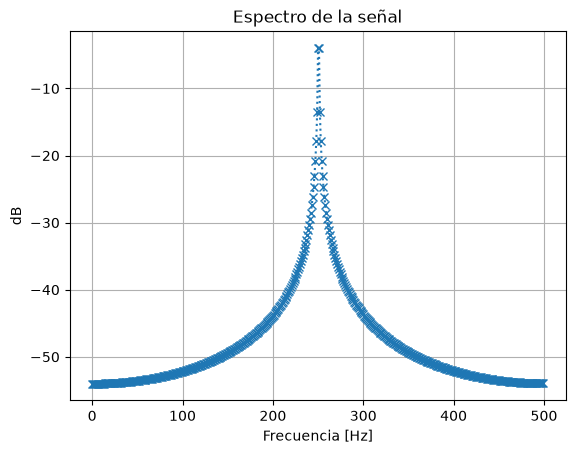

In [23]:
plt.figure()
plt.plot(eje_frec, dens_espc3,':x')
plt.title("Espectro de la señal")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("dB")
plt.grid()
plt.show()

En el gráfico se observa que la potencia se encuentra más desparramada que en el caso anterior. Esto ocurre porque la frecuencia de la señal, $250.5\,Hz$, se encuentra exactamente a la misma distancia de los bins de $250\,Hz$ y $251\,Hz$. Por este motivo, la potencia se reparte entre varias componentes frecuenciales y el pico máximo disminuye respecto del caso de $250.25\,Hz$. Sin embargo, aunque la potencia se encuentre distribuida entre varios bins, la potencia total de la señal no se pierde.

### B.

Ahora, a partir de la identidad de Parseval, vamos a comprobar que, aunque la potencia se encuentre repartida entre distintos bins, la potencia total de la señal se conserva y sigue siendo aproximadamente igual a 1.

La identidad de Parseval establece que la potencia de una señal puede calcularse tanto en el dominio del tiempo como en el dominio de la frecuencia, y ambos resultados deben coincidir. Esto significa que la transformada de Fourier no crea ni elimina potencia, sino que solamente cambia la forma en la que la observamos. En el dominio temporal, la potencia se calcula como $P_t=\frac{1}{N}\sum_{n=0}^{N-1}|x[n]|^2$, mientras que en el dominio de la frecuencia, utilizando la FFT normalizada como $Y[k]=\frac{1}{N}X[k]$, la potencia se obtiene como $P_f=\sum_{k=0}^{N-1}|Y[k]|^2$. Por lo tanto, según Parseval, se cumple que $P_t=P_f$. En este trabajo vamos a verificar que, aunque el desparramo espectral distribuya la potencia entre varios bins, la potencia total de la señal se conserva.

In [25]:
pot_tiempo = np.sum(xx**2) / N

pot_frec = np.sum(np.abs(yf)**2)

print(pot_tiempo)
print(pot_frec)

1.0000000000000002
1.0000000000000002


In [26]:
pot_tiempo2 = np.sum(xx2**2) / N

pot_frec2 = np.sum(np.abs(yf2)**2)

print(pot_tiempo2)
print(pot_frec2)

0.9989999999999998
0.9989999999999997


In [27]:
pot_tiempo3 = np.sum(xx3**2) / N

pot_frec3 = np.sum(np.abs(yf3)**2)

print(pot_tiempo3)
print(pot_frec3)

1.0000000000000004
1.0000000000000007


A partir de los resultados obtenidos se verifica la identidad de Parseval, ya que para los tres casos la potencia calculada en el dominio del tiempo coincide con la potencia calculada en el dominio de la frecuencia. Para $k=250$ se obtiene una potencia aproximadamente igual a $1$, al igual que para $k=250.5$. Las pequeñas diferencias respecto de $1$ se deben únicamente a errores numéricos de cálculo. En el caso de $k=250.25$ se obtiene una potencia aproximadamente igual a $0.999$, ya que en el intervalo de tiempo analizado no entra una cantidad entera de períodos de la señal. Sin embargo, lo importante es que la potencia obtenida en tiempo y en frecuencia sigue siendo la misma. De esta manera se comprueba que el desparramo espectral no implica una pérdida de potencia, sino que la potencia total simplemente se distribuye entre varios bins.

### C.

En esta parte del trabajo práctico se estudiará la técnica de zero padding, que consiste en agregar ceros al final de la señal antes de calcular la FFT. Esto permite reducir la separación entre los puntos en los que se evalúa el espectro, haciendo que la representación en frecuencia sea más densa y detallada. Sin embargo, esta técnica no agrega información nueva a la señal ni mejora su resolución física real, sino que únicamente permite visualizar con mayor detalle la forma del espectro.

In [28]:
N_padding = 10*N

xx_padding = np.concatenate((xx, np.zeros(9*N)))

eje_frec1 = np.arange(0, N_padding//2, ) * fs/N_padding

yf = 1/N * np.fft.fft(xx_padding)

XX_mod = np.abs(yf)

espectro = XX_mod**2

dens_espc = 10*np.log10(2*espectro[:N_padding//2])

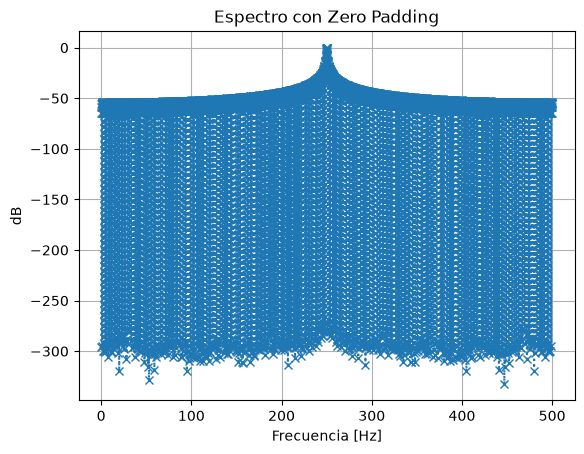

In [30]:
plt.figure()
plt.plot(eje_frec1, dens_espc,':x')
plt.title("Espectro con Zero Padding")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("dB")
plt.grid()
plt.show()

En este grafico que corresponde a $250\,Hz$ se observa que el máximo continúa ubicado exactamente en esa frecuencia, pero ahora se distingue con mayor claridad la forma del espectro alrededor del pico principal. La mayor cantidad de puntos permite visualizar el lóbulo central y los mínimos que aparecen a ambos lados, mostrando que el zero padding no modifica la frecuencia de la señal, sino que permite observar con más detalle la forma espectral que antes aparecía prácticamente como un único pico.

In [31]:
N_padding = 10*N

xx_padding = np.concatenate((xx2, np.zeros(9*N)))

eje_frec1 = np.arange(0, N_padding//2, ) * fs/N_padding

yf = 1/N * np.fft.fft(xx_padding)

XX_mod = np.abs(yf)

espectro = XX_mod**2

dens_espc = 10*np.log10(2*espectro[:N_padding//2])

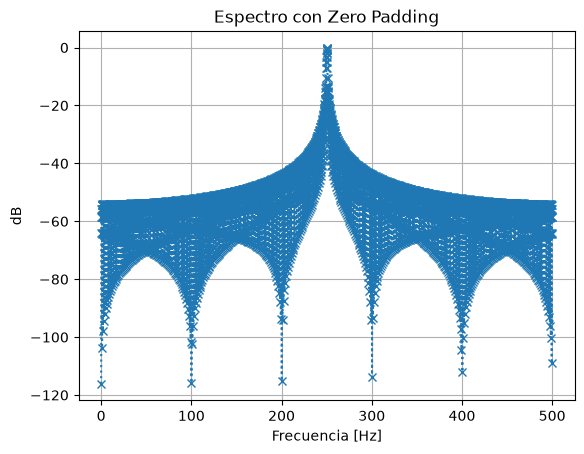

In [32]:
plt.figure()
plt.plot(eje_frec1, dens_espc,':x')
plt.title("Espectro con Zero Padding")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("dB")
plt.grid()
plt.show()

En este caso se observa que el máximo del espectro se encuentra alrededor de $250.25\,Hz$, mientras que la potencia se distribuye a ambos lados formando un lóbulo principal y varios lóbulos laterales. También aparecen mínimos pronunciados donde la potencia cae considerablemente. A diferencia del gráfico sin zero padding, ahora se puede distinguir con mayor claridad la forma completa del desparramo espectral y cómo disminuye la potencia a medida que nos alejamos de la frecuencia principal.

In [33]:
N_padding = 10*N

xx_padding = np.concatenate((xx3, np.zeros(9*N)))

eje_frec1 = np.arange(0, N_padding//2, ) * fs/N_padding

yf = 1/N * np.fft.fft(xx_padding)

XX_mod = np.abs(yf)

espectro = XX_mod**2

dens_espc = 10*np.log10(2*espectro[:N_padding//2])

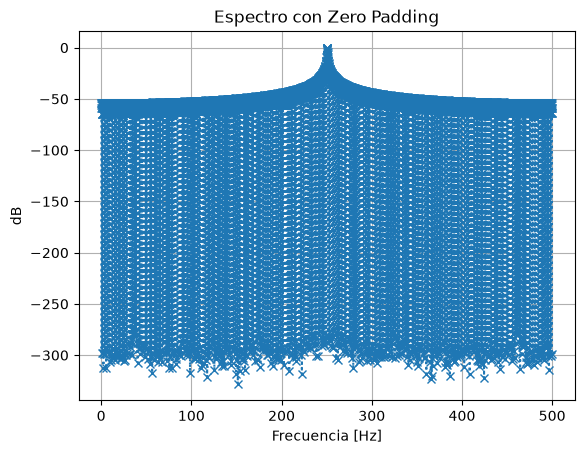

In [34]:
plt.figure()
plt.plot(eje_frec1, dens_espc,':x')
plt.title("Espectro con Zero Padding")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("dB")
plt.grid()
plt.show()

En el caso de $250.5\,Hz$, el zero padding permite que el nuevo gráfico de frecuencias incluya exactamente esta frecuencia, ya que los puntos se encuentran separados cada $0.1\,Hz$. Por este motivo, el máximo del espectro aparece alrededor de $250.5\,Hz$ y alcanza aproximadamente los $0\,dB$. A su alrededor se puede observar con mayor detalle la forma del lóbulo principal y la distribución espectral. Esto no significa que el desparramo haya desaparecido, sino que la mayor cantidad de puntos permite representar con más precisión la forma del espectro.

#### Conclusión

A partir de este trabajo se pudo observar cómo cambia el espectro de una señal senoidal según la relación entre su frecuencia y los bins de la DFT. Cuando la frecuencia coincide exactamente con uno de los bins, como en el caso de $250\,Hz$, la potencia queda concentrada principalmente en esa componente. En cambio, al alejar la frecuencia de un bin, como ocurre para $250.25\,Hz$ y $250.5\,Hz$, la potencia se distribuye entre varias componentes y aparece el fenómeno de desparramo espectral. Mediante la identidad de Parseval se verificó que este desparramo no implica una pérdida de potencia, ya que la potencia calculada en el dominio del tiempo coincide con la obtenida en el dominio de la frecuencia. Finalmente, mediante zero padding se logró observar con mayor detalle la forma del espectro al disminuir la separación entre los puntos de la FFT, aunque sin agregar información nueva ni mejorar la resolución física real de la señal.